importing required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_percentage_error
from xgboost import XGBRegressor

Loading the datasets 

In [2]:

demand_df = pd.read_excel('/kaggle/input/datasets/vishwasrajawat/ai-task/PGCB_date_power_demand.xlsx')

weather_df = pd.read_excel('/kaggle/input/datasets/vishwasrajawat/ai-task/weather_data.xlsx')

economic_df = pd.read_csv('/kaggle/input/datasets/vishwasrajawat/ai-task/economic_full_1.csv')

print(demand_df.head())
print(demand_df.info())
print(demand_df.shape)

             datetime  generation_mw  demand_mw  load_shedding   gas  \
0 2015-04-19 22:00:00         6323.0       6323              0     0   
1 2015-04-19 21:00:00         6667.0       6667              0     0   
2 2015-04-19 19:00:00         6897.0       6897              0  4415   
3 2015-04-19 18:30:00         6933.0       6933              0  4423   
4 2015-04-19 18:00:00         6874.0       6874              0  4319   

   liquid_fuel  coal  hydro  solar  wind  india_bheramara_hvdc  india_tripura  \
0            0     0      0    NaN   NaN                     0              0   
1            0     0      0    NaN   NaN                     0              0   
2         1836   161     41    NaN   NaN                   444              0   
3         1862   159     45    NaN   NaN                   444              0   
4         1892   155     65    NaN   NaN                   443              0   

   india_adani  nepal       remarks  
0          NaN    NaN           NaN  
1   

# ****Data preparation****

Proper datetime index,
Sorted,
No duplicate timestamps,
Consistent hourly structure

In [3]:

demand_df["datetime"] = pd.to_datetime(demand_df["datetime"])

# sort 
demand_df = demand_df.sort_values("datetime")

# removing duplicates 
demand_df = demand_df.drop_duplicates(subset=["datetime"])

# set index
demand_df = demand_df.set_index("datetime")

# enforce hourly frequency
demand_df = demand_df.asfreq("h")

i used 'asfreq("h")' to ensure every hour must exist, so my lag features are valid.

if missing → NaN appears

In [4]:
print(demand_df.shape)
print(demand_df.isna().sum().sort_values(ascending=False).head(10))
print(demand_df.index.min(), demand_df.index.max())

(89101, 14)
nepal            83968
remarks          83349
india_adani      82062
wind             71192
solar            21572
generation_mw     1055
coal              1055
liquid_fuel       1055
gas               1055
load_shedding     1055
dtype: int64
2015-04-19 00:00:00 2025-06-17 12:00:00


We now have 3 types of variables:

1) Good quality 
generation_mw
demand_mw
load_shedding
gas / coal / hydro

2) Medium quality
wind, solar (many gaps but still usable with care)


4) Bad / unreliable 
nepal
india_adani
remarks

Fix remaining sparse columns properly

In [5]:
df = demand_df.copy()
df = df.sort_index()

continuous_cols = [
    "generation_mw",
    "demand_mw",
    "load_shedding",
    "gas",
    "liquid_fuel",
    "coal",
    "hydro"
]

df[continuous_cols] = df[continuous_cols].ffill()

df["solar"] = df["solar"].fillna(0)
df["wind"] = df["wind"].fillna(0)
df["india_bheramara_hvdc"] = df["india_bheramara_hvdc"].fillna(0)

In [6]:
df.isna().sum()

generation_mw               0
demand_mw                   0
load_shedding               0
gas                         0
liquid_fuel                 0
coal                        0
hydro                       0
solar                       0
wind                        0
india_bheramara_hvdc        0
india_tripura            1055
india_adani             82062
nepal                   83968
remarks                 83349
dtype: int64

In [7]:
df = df.drop(columns=["remarks"])

In [8]:
print("Shape:", df.shape)

# checking time continuity
print("Index type:", type(df.index))

# checking duplicates in time
print("Duplicate timestamps:", df.index.duplicated().sum())

# checking sorting integrity
print("Is sorted:", df.index.is_monotonic_increasing)

# checking frequency guess
print("Time diff sample:")
print(df.index.to_series().diff().value_counts().head())

Shape: (89101, 13)
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Duplicate timestamps: 0
Is sorted: True
Time diff sample:
datetime
0 days 01:00:00    89100
Name: count, dtype: int64


now working on economic dataset

In [9]:
print(economic_df.columns)
print(economic_df.head(3))
print(economic_df.shape)

Index(['Country Name', 'Indicator Name', 'Indicator Code', '1960', '1961',
       '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970',
       '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979',
       '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988',
       '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997',
       '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
       '2025'],
      dtype='object')
  Country Name                                  Indicator Name  \
0            X  Intentional homicides, male (per 100,000 male)   
1            X        Battle-related deaths (number of people)   
2            X       Voice and Accountability: Percentile Rank   

      Indicator Code  1960  1961  1962  1963  1964  1965  1966  ...  

In [10]:
econ = economic_df.copy()

# keep only relevant columns
econ = econ.drop(columns=["Country Name"], errors="ignore")

# set indicator as index
econ = econ.set_index(["Indicator Name", "Indicator Code"])

In [11]:
econ_yearly = econ.T

# convert index (years) to numeric
econ_yearly.index = econ_yearly.index.astype(int)

print(econ_yearly.shape)
print(econ_yearly.head())

(66, 1516)
Indicator Name Intentional homicides, male (per 100,000 male)  \
Indicator Code                              VC.IHR.PSRC.MA.P5   
1960                                                      NaN   
1961                                                      NaN   
1962                                                      NaN   
1963                                                      NaN   
1964                                                      NaN   

Indicator Name Battle-related deaths (number of people)  \
Indicator Code                              VC.BTL.DETH   
1960                                                NaN   
1961                                                NaN   
1962                                                NaN   
1963                                                NaN   
1964                                                NaN   

Indicator Name Voice and Accountability: Percentile Rank  \
Indicator Code                                VA.PER.RNK   

In [12]:
econ_yearly.columns = [
    f"{col[0]}__{col[1]}" if isinstance(col, tuple) else col
    for col in econ_yearly.columns
]

econ_yearly.columns = [
    col.replace("Indicator Name ", "")
       .replace("Indicator Code ", "")
       .replace(" ", "_")
       .replace(",", "")
       .replace("(", "")
       .replace(")", "")
       .lower()
    for col in econ_yearly.columns
]

print(econ_yearly.shape)
print(econ_yearly.columns[:10])

(66, 1516)
Index(['intentional_homicides_male_per_100000_male__vc.ihr.psrc.ma.p5',
       'battle-related_deaths_number_of_people__vc.btl.deth',
       'voice_and_accountability:_percentile_rank__va.per.rnk',
       'transport_services_%_of_commercial_service_exports__tx.val.tran.zs.wt',
       'computer_communications_and_other_services_%_of_commercial_service_exports__tx.val.othr.zs.wt',
       'merchandise_exports_by_the_reporting_economy_residual_%_of_total_merchandise_exports__tx.val.mrch.rs.zs',
       'merchandise_exports_to_low-_and_middle-income_economies_in_latin_america_&_the_caribbean_%_of_total_merchandise_exports__tx.val.mrch.r3.zs',
       'merchandise_exports_to_high-income_economies_%_of_total_merchandise_exports__tx.val.mrch.hi.zs',
       'manufactures_exports_%_of_merchandise_exports__tx.val.manf.zs.un',
       'food_exports_%_of_merchandise_exports__tx.val.food.zs.un'],
      dtype='object')


In [13]:
# check current index
print(econ_yearly.index[:5])
print(type(econ_yearly.index[0]))

# convert index to integer (year)
econ_yearly.index = econ_yearly.index.astype(int)

# sort (just to be safe)
econ_yearly = econ_yearly.sort_index()

# verify
print(econ_yearly.index[:5])
print(type(econ_yearly.index[0]))

Index([1960, 1961, 1962, 1963, 1964], dtype='int64')
<class 'numpy.int64'>
Index([1960, 1961, 1962, 1963, 1964], dtype='int64')
<class 'numpy.int64'>


In [14]:
print(econ_yearly.isna().sum().sort_values(ascending=False).head(10))

intentional_homicides_male_per_100000_male__vc.ihr.psrc.ma.p5                                        66
net_oda_provided_total_current_us$__dc.oda.totl.cd                                                   66
condom_use_population_ages_15-24_female_%_of_females_ages_15-24__sh.con.1524.fe.zs                   66
intentional_homicides_female_per_100000_female__vc.ihr.psrc.fe.p5                                    66
children_0-14_living_with_hiv__sh.hiv.0014                                                           66
proportion_of_time_spent_on_unpaid_domestic_and_care_work_female_%_of_24_hour_day__sg.tim.uwrk.fe    66
research_and_development_expenditure_%_of_gdp__gb.xpd.rsdv.gd.zs                                     66
net_official_flows_from_un_agencies_unpbf_current_us$__dt.nfl.unpb.cd                                66
net_official_flows_from_un_agencies_unep_current_us$__dt.nfl.unep.cd                                 66
social_contributions_current_lcu__gc.rev.socl.cn                

In [15]:
# drop columns that are completely NaN
econ_yearly = econ_yearly.dropna(axis=1, how='all')

# check shape after dropping
print(econ_yearly.shape)

(66, 1460)


In [16]:
econ_yearly.isna().sum().sort_values(ascending=False).head(5)

learning_poverty:_share_of_male_children_at_the_end-of-primary_age_below_minimum_reading_proficiency_adjusted_by_out-of-school_children_%__se.lpv.prim.ma      65
learning_poverty:_share_of_female_children_at_the_end-of-primary_age_below_minimum_reading_proficiency_adjusted_by_out-of-school_children_%__se.lpv.prim.fe    65
arms_exports_sipri_trend_indicator_values__ms.mil.xprt.kd                                                                                                      65
annualized_average_growth_rate_in_per_capita_real_survey_mean_consumption_or_income_total_population_%__si.spr.pcap.zg                                         65
children_in_employment_self-employed_%_of_children_in_employment_ages_7-14__sl.slf.0714.zs                                                                     65
dtype: int64

removing columns with more than half data missing

In [17]:
# calculating missing ratio
missing_ratio = econ_yearly.isna().mean()

# keeping columns with <= 50% missing
econ_yearly = econ_yearly.loc[:, missing_ratio <= 0.5]

print(econ_yearly.shape)

(66, 654)


In [18]:
# interpolate along time (year-wise)
econ_yearly = econ_yearly.interpolate(method='linear', axis=0)

# check remaining missing values
print(econ_yearly.isna().sum().sum())

8083


In [19]:
# fill remaining edge NaNs
econ_yearly = econ_yearly.ffill().bfill()

# final check
print(econ_yearly.isna().sum().sum())

0


 **Align economic data with hourly data**

In [20]:
# create year column from datetime index
demand_df["year"] = demand_df.index.year

# check
print(demand_df[["year"]].head())

                     year
datetime                 
2015-04-19 00:00:00  2015
2015-04-19 01:00:00  2015
2015-04-19 02:00:00  2015
2015-04-19 03:00:00  2015
2015-04-19 04:00:00  2015


In [21]:
print(demand_df["year"].value_counts().head())

year
2016    8784
2024    8784
2020    8784
2021    8760
2017    8760
Name: count, dtype: int64


merge demand and econ

In [22]:
# reset index temporarily (important for merge)
demand_df_reset = demand_df.reset_index()

# merge with economic data
merged_df = demand_df_reset.merge(
    econ_yearly,
    left_on="year",
    right_index=True,
    how="left"
)

# set datetime back as index
merged_df = merged_df.set_index("datetime")

# check shape
print(merged_df.shape)

(89101, 669)


In [23]:
merged_df.isna().sum().sort_values(ascending=False).head(15)

nepal                                                                 83968
remarks                                                               83349
india_adani                                                           82062
wind                                                                  71192
solar                                                                 21572
generation_mw                                                          1055
india_tripura                                                          1055
india_bheramara_hvdc                                                   1055
hydro                                                                  1055
coal                                                                   1055
liquid_fuel                                                            1055
gas                                                                    1055
load_shedding                                                          1055
demand_mw   

now lets fill 0 inplace of NaN 

In [24]:
cols_fill_zero = ["nepal", "india_adani", "wind", "solar"]
merged_df[cols_fill_zero] = merged_df[cols_fill_zero].fillna(0)



In [25]:
merged_df[cols_fill_zero].isna().sum()

nepal          0
india_adani    0
wind           0
solar          0
dtype: int64

for some columns at start and end 

In [26]:
df = merged_df.ffill().bfill()

In [27]:
print("Remaining NaNs:", df.isna().sum().sum())

Remaining NaNs: 0


now working on weatheer dataset

In [28]:
weather_df.head()
weather_df.shape
weather_df.columns

Index(['latitude', 'longitude', 'elevation', 'utc_offset_seconds', 'timezone',
       'timezone_abbreviation', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Unnamed: 9'],
      dtype='object')

here we need to skip 3 rows to read actual data


In [29]:
weather_df = pd.read_excel('/kaggle/input/datasets/vishwasrajawat/ai-task/weather_data.xlsx', skiprows=3)

In [30]:
weather_df.head()
weather_df.columns
weather_df.shape

(107304, 10)

In [31]:
weather_df.columns
weather_df.head(3)

,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0


In [32]:
weather_df.columns = weather_df.columns.str.strip()

In [33]:
weather_df["time"] = pd.to_datetime(weather_df["time"])
weather_df = weather_df.set_index("time")
weather_df = weather_df.sort_index()

In [34]:
print(weather_df.columns)
print(weather_df.index)

Index(['temperature_2m (°C)', 'relative_humidity_2m (%)',
       'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)',
       'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)',
       'cloud_cover (%)', 'sunshine_duration (s)'],
      dtype='object')
DatetimeIndex(['2014-01-01 00:00:00', '2014-01-01 01:00:00',
               '2014-01-01 02:00:00', '2014-01-01 03:00:00',
               '2014-01-01 04:00:00', '2014-01-01 05:00:00',
               '2014-01-01 06:00:00', '2014-01-01 07:00:00',
               '2014-01-01 08:00:00', '2014-01-01 09:00:00',
               ...
               '2026-03-29 14:00:00', '2026-03-29 15:00:00',
               '2026-03-29 16:00:00', '2026-03-29 17:00:00',
               '2026-03-29 18:00:00', '2026-03-29 19:00:00',
               '2026-03-29 20:00:00', '2026-03-29 21:00:00',
               '2026-03-29 22:00:00', '2026-03-29 23:00:00'],
              dtype='datetime64[ns]', name='time', length=107304, freq=None)


In [35]:
weather_df.isna().sum().sort_values(ascending=False)

temperature_2m (°C)               0
relative_humidity_2m (%)          0
apparent_temperature (°C)         0
precipitation (mm)                0
dew_point_2m (°C)                 0
soil_temperature_0_to_7cm (°C)    0
wind_direction_10m (°)            0
cloud_cover (%)                   0
sunshine_duration (s)             0
dtype: int64

merging

In [36]:
# merge on datetime index
df = df.merge(weather_df, left_index=True, right_index=True, how="left")

In [37]:
df.shape
df.isna().sum().sort_values(ascending=False).head(10)

sunshine_duration (s)                                                   0
generation_mw                                                           0
demand_mw                                                               0
load_shedding                                                           0
gas                                                                     0
liquid_fuel                                                             0
net_financial_flows_others_nfl_current_us$__dt.nfl.moth.cd              0
ppg_commercial_banks_nfl_current_us$__dt.nfl.pcbk.cd                    0
ppg_other_private_creditors_nfl_current_us$__dt.nfl.prop.cd             0
access_to_electricity_urban_%_of_urban_population__eg.elc.accs.ur.zs    0
dtype: int64

In [38]:
df.shape
df.columns

Index(['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       ...
       'net_bilateral_aid_flows_from_dac_donors_japan_current_us$__dc.dac.jpnl.cd',
       'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)',
       'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)',
       'cloud_cover (%)', 'sunshine_duration (s)'],
      dtype='object', length=678)

In [39]:
df.shape
df.isna().sum().sort_values(ascending=False).head(15)

sunshine_duration (s)                                                            0
generation_mw                                                                    0
demand_mw                                                                        0
load_shedding                                                                    0
gas                                                                              0
liquid_fuel                                                                      0
net_financial_flows_others_nfl_current_us$__dt.nfl.moth.cd                       0
ppg_commercial_banks_nfl_current_us$__dt.nfl.pcbk.cd                             0
ppg_other_private_creditors_nfl_current_us$__dt.nfl.prop.cd                      0
access_to_electricity_urban_%_of_urban_population__eg.elc.accs.ur.zs             0
electricity_production_from_hydroelectric_sources_%_of_total__eg.elc.hyro.zs     0
electricity_production_from_oil_sources_%_of_total__eg.elc.petr.zs               0
alte

In [40]:
df.index.is_monotonic_increasing

True

In [41]:
df.index.duplicated().sum()

np.int64(0)

# ***feature engineering***

time based

In [42]:
df["hour"] = df.index.hour
df["day"] = df.index.day
df["month"] = df.index.month
df["dayofweek"] = df.index.dayofweek
df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

In [43]:
df[["hour","day","month","dayofweek","is_weekend"]].head()

,hour,day,month,dayofweek,is_weekend
datetime,,,,,
2015-04-19 00:00:00,0,19,4,6,1
2015-04-19 01:00:00,1,19,4,6,1
2015-04-19 02:00:00,2,19,4,6,1
2015-04-19 03:00:00,3,19,4,6,1
2015-04-19 04:00:00,4,19,4,6,1


lag based

In [44]:
df["demand_lag_1"] = df["demand_mw"].shift(1)
df["demand_lag_24"] = df["demand_mw"].shift(24)
df["demand_lag_168"] = df["demand_mw"].shift(168)

In [45]:
df[["demand_mw","demand_lag_1","demand_lag_24","demand_lag_168"]].head(30)

,demand_mw,demand_lag_1,demand_lag_24,demand_lag_168
datetime,,,,
2015-04-19 00:00:00,4821.0,NaN,NaN,NaN
2015-04-19 01:00:00,3612.0,4821.0,NaN,NaN
2015-04-19 02:00:00,3727.0,3612.0,NaN,NaN
2015-04-19 03:00:00,3632.0,3727.0,NaN,NaN
2015-04-19 04:00:00,3641.0,3632.0,NaN,NaN
2015-04-19 05:00:00,3283.0,3641.0,NaN,NaN
2015-04-19 06:00:00,3444.0,3283.0,NaN,NaN
2015-04-19 07:00:00,3592.0,3444.0,NaN,NaN
2015-04-19 08:00:00,4049.0,3592.0,NaN,NaN


In [46]:
df["demand_mw"].isna().sum()

np.int64(0)

In [47]:
df[df["demand_mw"].isna()].head()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,...,cloud_cover (%),sunshine_duration (s),hour,day,month,dayofweek,is_weekend,demand_lag_1,demand_lag_24,demand_lag_168
datetime,,,,,,,,,,,,,,,,,,,,,


In [48]:
df["demand_mw"] = df["demand_mw"].interpolate()
df["demand_mw"] = df["demand_mw"].ffill().bfill()

In [49]:
df["demand_lag_1"] = df["demand_mw"].shift(1)
df["demand_lag_24"] = df["demand_mw"].shift(24)
df["demand_lag_168"] = df["demand_mw"].shift(168)

rolling based

In [50]:
df["rolling_mean_24"] = df["demand_mw"].rolling(24).mean()
df["rolling_mean_168"] = df["demand_mw"].rolling(168).mean()

df["rolling_std_24"] = df["demand_mw"].rolling(24).std()

In [51]:
df[["demand_mw","demand_lag_1","demand_lag_24","demand_lag_168"]].isna().sum()

demand_mw           0
demand_lag_1        1
demand_lag_24      24
demand_lag_168    168
dtype: int64

**now because of demand_lag_168 initial 168 rows have NaN because they have no 168 hours ago

In [52]:
df = df.iloc[168:]

In [53]:
df[["demand_mw","demand_lag_1","demand_lag_24","demand_lag_168"]].isna().sum()

demand_mw         0
demand_lag_1      0
demand_lag_24     0
demand_lag_168    0
dtype: int64

In [54]:
df.shape

(88933, 689)

In [55]:
df = df.drop(columns=["remarks"])

 **splitting data**

In [56]:
df = df.sort_index()

In [57]:
train = df[df.index.year <= 2023]
test = df[df.index.year >= 2024]

In [58]:
X_train = train.drop(columns=["demand_mw"])
y_train = train["demand_mw"]

X_test = test.drop(columns=["demand_mw"])
y_test = test["demand_mw"]

In [59]:
print("Train:", train.shape)
print("Test:", test.shape)

print("Train years:", train.index.year.min(), "to", train.index.year.max())
print("Test years:", test.index.year.min(), "to", test.index.year.max())

Train: (76128, 688)
Test: (12805, 688)
Train years: 2015 to 2023
Test years: 2024 to 2025


# **training model**

**using xgboost first**

In [60]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [61]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [62]:
y_pred = model.predict(X_test)

evaluate

In [63]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 290.1657396059584
RMSE: 1500.5332964411582


In [64]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE (% error):", mape)

MAPE (% error): 3.5742308351387972


Feature Importance

In [65]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(15)

,feature,importance
0,generation_mw,0.486160
681,demand_lag_1,0.160788
682,demand_lag_24,0.053447
1,load_shedding,0.029692
672,soil_temperature_0_to_7cm (°C),0.028614
669,apparent_temperature (°C),0.028525
684,rolling_mean_24,0.018863
4,coal,0.016426
86,net_bilateral_aid_flows_from_dac_donors_united...,0.014483
3,liquid_fuel,0.013097


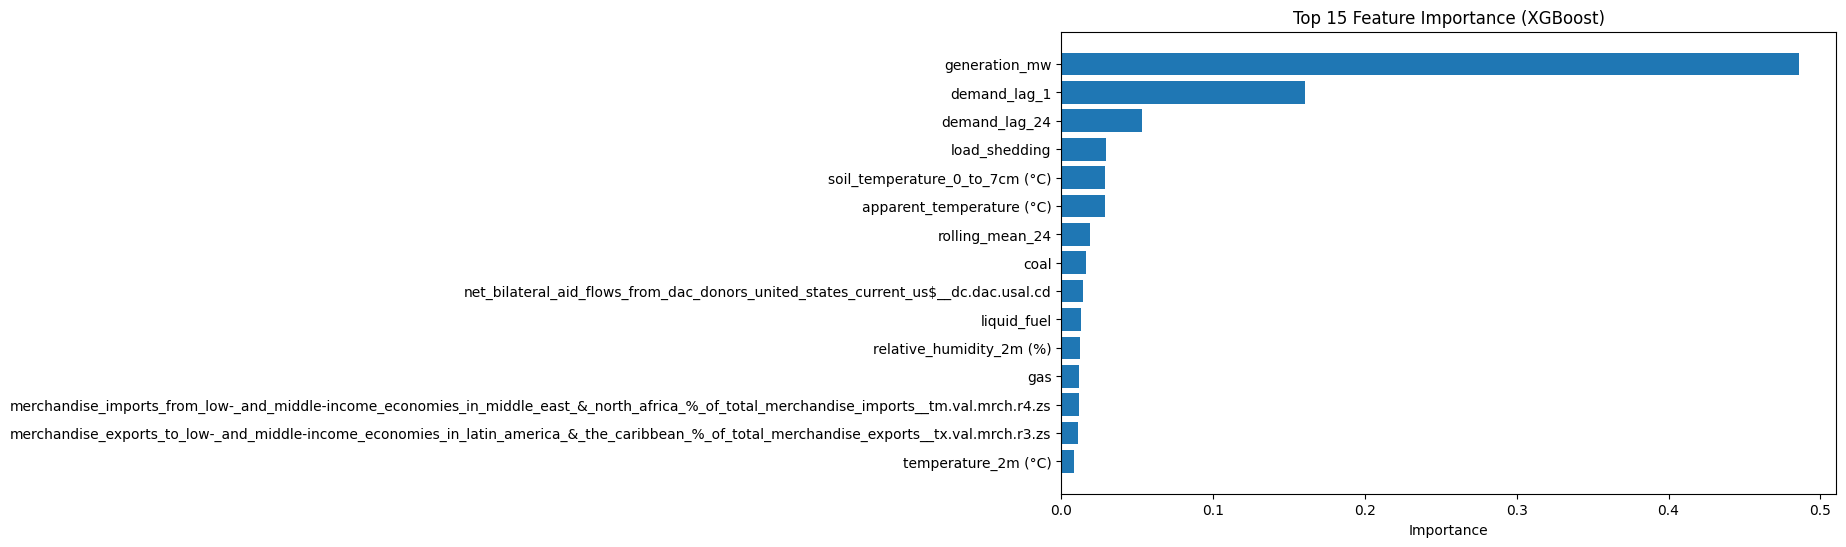

In [66]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top 15 Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.show()

no feature have importance less than 0.01, so i am not droping any feature here

**Hyperparameter Optimization**

In [67]:
model = XGBRegressor(
    n_estimators=800,
learning_rate=0.06,
max_depth=5,
subsample=0.8,
colsample_bytree=0.8,
min_child_weight=3,
gamma=0.1,
reg_lambda=2
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.06, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=None, num_parallel_tree=None, ...)

In [68]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.06, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=None, num_parallel_tree=None, ...)

In [69]:
y_pred = model.predict(X_test)

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 348.60015780960197
RMSE: 1501.4988620665479


In [72]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE (% error):", mape)

MAPE (% error): 4.241569916976579


After changing the model parameters, the error increased instead of decreasing. The new settings made the model more restricted and less flexible, so it could not learn the patterns in the data properly.

The original settings worked better because they gave a good balance between learning the data and avoiding overfitting. This shows that making the model more complex or more controlled does not always improve performance.

# **lets try using randomforest**

In [73]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [74]:
y_pred_rf = rf_model.predict(X_test)

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("RF MAE:", mae_rf)
print("RF RMSE:", rmse_rf)

RF MAE: 255.84583127740902
RF RMSE: 2830.008797621546


In [76]:
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
print("RF MAPE:", mape_rf)

RF MAPE: 3.323323311478855


**Hee we can see randomforest is giving more accuracy than NN and XGBoost**

**This is likely because my features already captured strong temporal patterns, making the problem easier, and Random Forest handled the variance well without requiring much tuning**

# *lets try using neural networks*

In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [78]:
from sklearn.neural_network import MLPRegressor

nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(64, 32), random_state=42)

In [79]:
y_pred_nn = nn_model.predict(X_test_scaled)

In [80]:
from sklearn.metrics import mean_absolute_error

mae_nn = mean_absolute_error(y_test, y_pred_nn)
print("NN MAE:", mae_nn)

NN MAE: 2038.689164624429


In [81]:
mape = np.mean(np.abs((y_test - y_pred_nn) / y_test)) * 100
print("MAPE (% error):", mape)

MAPE (% error): 21.237346946341727


Neural networks performed worse than tree-based models in this case because the dataset consists of structured, feature-engineered tabular time-series data. Tree-based models handle lag and rolling features more effectively, while neural networks are more sensitive to data distribution changes and require more careful tuning.